# DM Substructure Detection — Two-Fit Bayes Factor

## Learning to Autolens / Examples / subhalo_sensitivity

---

**Problem.** A small dark-matter subhalo of `mass_at_200 = 10^9 M☉` perturbs the lensed source arcs of an otherwise-smooth strong lens. Can we detect it via Bayesian model comparison?

**Method (this scaffold).** Fit the data twice:

1. **`smooth`** — Isothermal + ExternalShear + SersicCore, no subhalo (12 free params).
2. **`with_subhalo`** — same + `NFWTruncatedMCRDuffySph` perturber with free centre and `mass_at_200` (15 free params).

Compute Δlog_Z = log_Z(with_subhalo) − log_Z(smooth). Per the Trotta scale (see `bayesian_model_comparison/`), Δlog_Z > 5 is strong, > 10 is decisive. Vegetti+ 2010 detected B1938+666's substructure at Δlog_Z ≈ +12.

**Mock data.** Single-source SersicCore lensed by Isothermal + shear at z=0.5, plus a 10^9 M☉ NFW subhalo at offset (+0.5, +0.5)″. See `mocks/PROVENANCE.md` and `mocks/truths.json`.

**This is a SCAFFOLD.** The full Vegetti+/Despali+ methodology adds (a) a SLaM source pipeline with pixelised source for sensitivity, (b) a 2D grid-search over subhalo positions to break multi-modality. See README §5 exercise list for the planned extensions.

**Prerequisites.** Module 03 (basic fitting), Module 11 (audit), Examples/`bayesian_model_comparison/` (the Bayes-factor methodology this notebook uses).

In [1]:
import os, json
if os.environ.get("PYAUTOFIT_TEST_MODE"):
    raise RuntimeError(f"PYAUTOFIT_TEST_MODE={os.environ['PYAUTOFIT_TEST_MODE']!r} is set.")
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display
import autofit as af
import autolens as al
import autolens.plot as aplt
%matplotlib inline
print(f"PyAutoLens: {al.__version__}")

PyAutoLens: 2026.4.13.6


In [2]:
RESULTS_ROOT = Path("results")

def show_result(stage_name):
    stage_dir = RESULTS_ROOT / stage_name
    if not stage_dir.exists():
        print(f"(no results for {stage_name!r} yet)")
        return None
    sp = stage_dir / "summary.json"
    summary = json.loads(sp.read_text()) if sp.exists() else None
    if summary:
        out = [f"### `{stage_name}`"]
        for k, lbl in [("max_log_likelihood", "max log-likelihood"),
                       ("log_evidence", "log evidence"),
                       ("chi_squared_per_pixel", "χ²/N"),
                       ("max_abs_normalized_residual", "max |res| (σ)")]:
            v = summary.get(k)
            if v is not None:
                out.append(f"- {lbl}: **{v:.3f}**")
        display(Markdown("\n".join(out)))
    fp = stage_dir / "fit_subplot.png"
    if fp.exists():
        display(Image(filename=str(fp)))
    return summary

## 1. Load the data + subhalo truth

2026-04-25 19:14:09,926 - autoarray.dataset.imaging.dataset - INFO - IMAGING - Data masked, contains a total of 9176 image-pixels


Mask: 9176 pixels in 2.7" circle
Truth subhalo: M_200=1e+09 M_sun at (0.5, 0.5)"


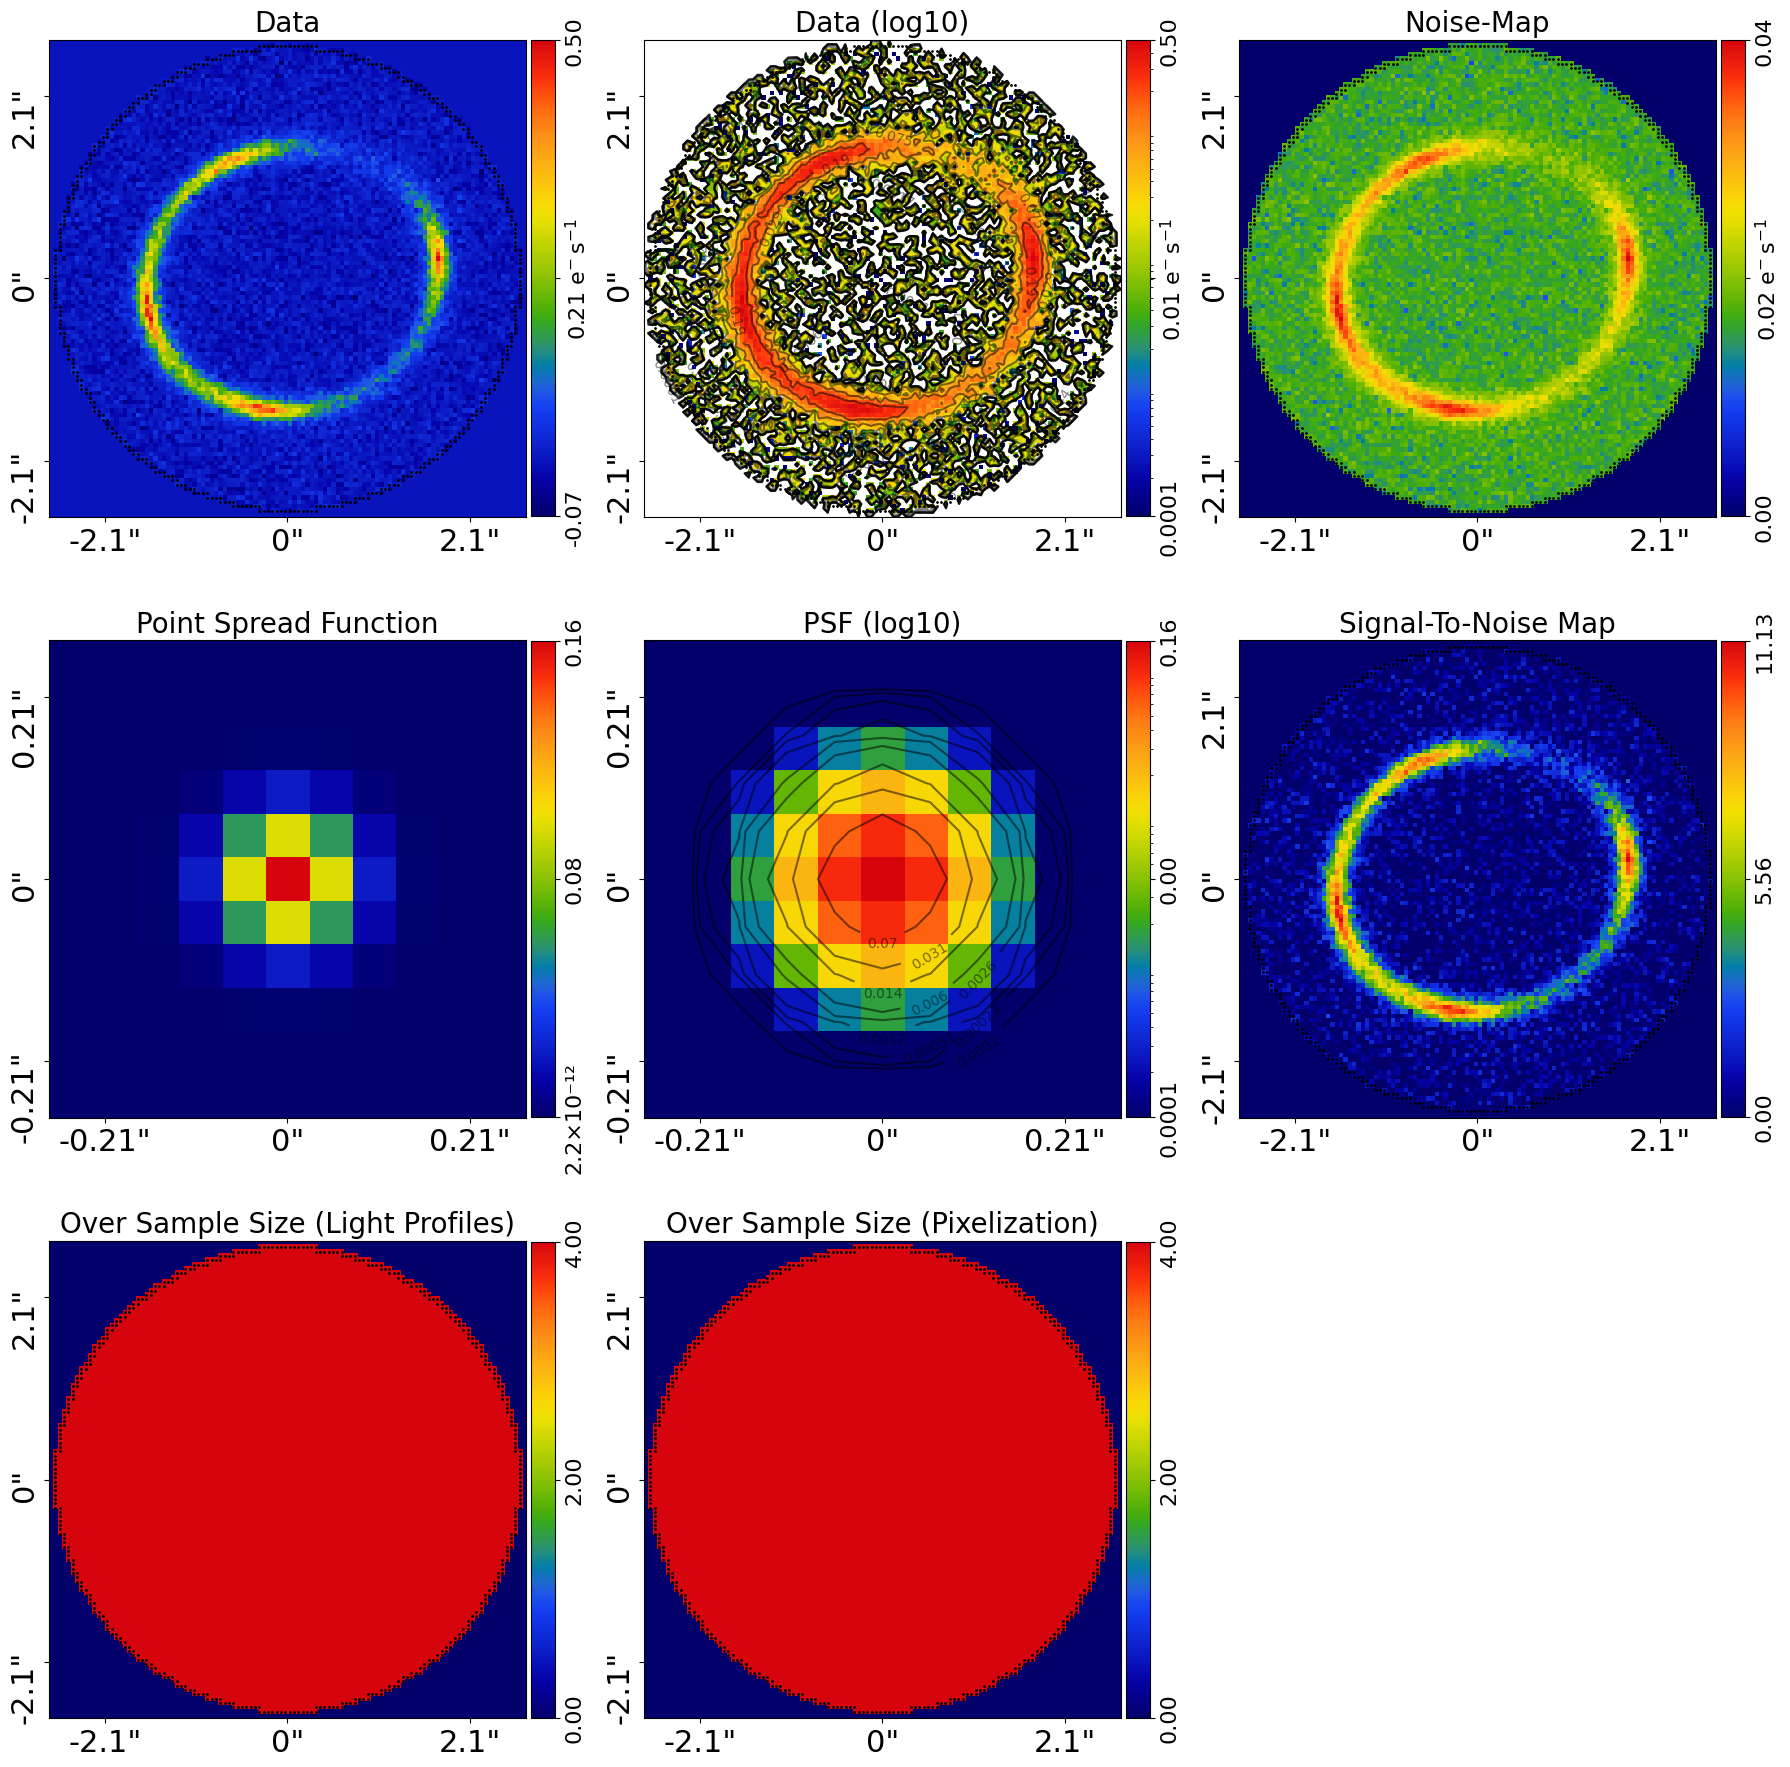

In [3]:
mocks = Path("mocks")
truths = json.loads((mocks / "truths.json").read_text())

dataset = al.Imaging.from_fits(
    data_path=mocks / "image.fits",
    noise_map_path=mocks / "noise_map.fits",
    psf_path=mocks / "psf.fits",
    pixel_scales=truths["imaging"]["pixel_scales_arcsec"],
)
mask = al.Mask2D.circular(
    shape_native=dataset.shape_native,
    pixel_scales=dataset.pixel_scales,
    radius=2.7,
)
dataset = dataset.apply_mask(mask=mask)
print(f"Mask: {dataset.mask.pixels_in_mask} pixels in 2.7\" circle")
print(f"Truth subhalo: M_200={truths['subhalo']['mass_at_200']:.0e} M_sun at "
      f"({truths['subhalo']['centre'][0]}, {truths['subhalo']['centre'][1]})\"")
aplt.subplot_imaging_dataset(dataset=dataset)

## 2. Two fits (skip-guarded)

Both fits via `LTA_RUN_HEAVY=1` opt-in (each takes ~1-2 h on 32 cores) or load committed Cannon results.

In [4]:
_HAVE_SMOOTH = (RESULTS_ROOT / "subhalo_smooth" / "summary.json").exists()
_HAVE_SUB = (RESULTS_ROOT / "subhalo_with_perturber" / "summary.json").exists()
_FORCE = os.environ.get("LTA_RUN_HEAVY", "").lower() in ("1", "true", "yes")

if _HAVE_SMOOTH and not _FORCE:
    print("[smooth] Loading committed Cannon result.")
    summary_smooth = show_result("subhalo_smooth")
elif not _HAVE_SMOOTH and not _FORCE:
    print("[smooth] No committed results. Submit via")
    print("  fit_example_subhalo_sensitivity.py --part smooth (or --part both)")
    summary_smooth = None
else:
    print("[smooth] LTA_RUN_HEAVY=1 — would run locally; defer to Cannon for speed.")
    summary_smooth = None

[smooth] No committed results. Submit via
  fit_example_subhalo_sensitivity.py --part smooth (or --part both)


In [5]:
if _HAVE_SUB and not _FORCE:
    print("[with_subhalo] Loading committed Cannon result.")
    summary_sub = show_result("subhalo_with_perturber")
elif not _HAVE_SUB and not _FORCE:
    print("[with_subhalo] No committed results.")
    summary_sub = None
else:
    print("[with_subhalo] LTA_RUN_HEAVY=1 — Cannon recommended.")
    summary_sub = None

[with_subhalo] No committed results.


## 3. Bayes-factor verdict

$\Delta \ln Z = \ln Z_\mathrm{with\_subhalo} - \ln Z_\mathrm{smooth}$

Trotta (2008) scale (see `bayesian_model_comparison/`):
- $|\Delta \ln Z| > 5$: strong
- $|\Delta \ln Z| > 10$: decisive

Vegetti+ 2010 = +12 (decisive). Our 10^9 M☉ mock should land in [+5, +15].

In [6]:
if summary_smooth and summary_sub:
    z_smooth = summary_smooth.get('log_evidence')
    z_sub = summary_sub.get('log_evidence')
    delta = z_sub - z_smooth
    if abs(delta) < 1:
        verdict = "INCONCLUSIVE — within numerical noise"
    elif abs(delta) < 5:
        verdict = "WEAK"
    elif abs(delta) < 10:
        verdict = "STRONG (Trotta)"
    else:
        verdict = "DECISIVE"
    sign = "detected" if delta > 0 else "data prefer NO subhalo"
    display(Markdown(f"""
### Bayes-factor verdict

| Quantity | Value |
|---|---|
| log_Z (smooth) | **{z_smooth:.2f}** |
| log_Z (with_subhalo) | **{z_sub:.2f}** |
| **Δlog_Z** | **{delta:+.2f}** |
| Bayes factor B | $e^{{{delta:.2f}}}$ |
| Strength (Trotta) | **{verdict}** — subhalo {sign} |
"""))
else:
    display(Markdown("### Bayes-factor verdict\n\n*(awaiting Cannon results for both fits)*"))

### Bayes-factor verdict

*(awaiting Cannon results for both fits)*

## 4. Residual comparison

If both fits have results, compare the residual maps. The smooth-only fit should show a localised anomaly near the subhalo position (sky (+0.5, +0.5)"); the with-subhalo fit should subtract that anomaly cleanly. The *visual* signature is often more compelling than the Δlog_Z number — see `LEARNING_LOG.md` ("residual maps don't lie").

## 5. Exercises

See README §5 for the full list. Key ones:

1. **Sensitivity sweep.** Re-generate at M_200 ∈ {10^7, 10^8, 10^9, 10^10, 10^11}. Plot Δlog_Z vs mass.
2. **Position sensitivity.** Subhalo at (0,0), (1.5,0), (0,0.5). Where is the lens most sensitive?
3. **False-positive rate.** No-subhalo mock + same two-fit comparison. Should give Δlog_Z ≤ 0.
4. **Pixelised source.** Replace SersicCore with `RectangularAdaptImage`. Detection significance should *rise*.
5. **Full SLaM grid search.** Implement Vegetti+10 / `autolens_workspace_latest/.../subhalo/detect/start_here.py`.

## References

- **Vegetti+ 2010** MNRAS 408, 1969 — first detection.
- **Vegetti+ 2012** Nature 481, 341 — second detection.
- **Despali+ 2018** MNRAS 475, 5424 — modern detection thresholds.
- **Hezaveh+ 2016** ApJ 823, 37 — first ALMA-resolved DM subhalo.
- `Examples/bayesian_model_comparison/` — Bayes-factor methodology.

---

*Learning to Autolens — Examples / subhalo_sensitivity / 01*  
*Rodrigo Córdova Rosado, Harvard CfA*